## DS 6021: Intro to Predictive Modeling 
## Lab 4: Intro to sklearn + Feature Transformations 
### Fiona St. Clair
***

AI Disclosure: I used Claude AI to help draft and run the code for this lab, using the in-class notebooks and my Lab 3 solution as references and checked it by comparing outputs across methods where the lab asked me to confirm they matched.
***

## Part 1: From statsmodels to scikit-learn

### Question 1

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

penguins = pd.read_csv('../../../data/penguins.csv')
cols_needed = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
d = penguins.dropna(subset=cols_needed).copy()
print("n penguins:", len(d))

model1 = smf.ols('body_mass_g ~ flipper_length_mm + C(sex) + C(species)', data=d).fit()
print(model1.params.round(3))
print("R2:", round(model1.rsquared, 4))

n penguins: 333
Intercept                 -365.817
C(sex)[T.male]             530.381
C(species)[T.Chinstrap]    -87.634
C(species)[T.Gentoo]       836.260
flipper_length_mm           20.025
dtype: float64
R2: 0.8669


**Reference level for sex: female** 
**Reference level for species: Adelie. R squared = 0.8669**

**Interpretation of C(species)[T.Gentoo]: holding flipper length and sex fixed, a Gentoo penguin is predicted to weigh about 836 grams more than an Adelie penguin on average.**

### Question 2

In [2]:
X = pd.get_dummies(d[['flipper_length_mm', 'sex', 'species']], columns=['sex', 'species'], drop_first=True)
y = d['body_mass_g']

lr = LinearRegression().fit(X, y)
print(X.columns.tolist())
print("intercept:", lr.intercept_)
print("coefs:", lr.coef_)
print("R2:", lr.score(X, y))

['flipper_length_mm', 'sex_male', 'species_Chinstrap', 'species_Gentoo']
intercept: -365.81744976158916
coefs: [ 20.02491543 530.38109449 -87.63447792 836.26000815]
R2: 0.8668883562330879


**a. The intercept, coefficients, and R squared all match the statsmodels output from Question 1 once you line up the dummy columns with the statsmodels reference levels.**

**b. sklearn's `LinearRegression` doesn't give us standard errors or confidence intervals directly, but we could either fit the same X and y in statsmodels or potentially bootstrap.**

### Question 3

In [3]:
X_oh = pd.get_dummies(d[['flipper_length_mm', 'sex', 'species']], columns=['sex', 'species'], drop_first=False)
print(X_oh.columns.tolist())

lr_oh = LinearRegression(fit_intercept=True).fit(X_oh, y)
coefs_oh = dict(zip(X_oh.columns, lr_oh.coef_))
print("intercept:", lr_oh.intercept_)
print("coefs:", coefs_oh)
print("R2:", lr_oh.score(X_oh, y))

print("predictions match Q2?", np.allclose(lr.predict(X), lr_oh.predict(X_oh)))

print("Chinstrap - Adelie:", coefs_oh['species_Chinstrap'] - coefs_oh['species_Adelie'])
print("Gentoo - Adelie:", coefs_oh['species_Gentoo'] - coefs_oh['species_Adelie'])
print("male - female:", coefs_oh['sex_male'] - coefs_oh['sex_female'])

['flipper_length_mm', 'sex_female', 'sex_male', 'species_Adelie', 'species_Chinstrap', 'species_Gentoo']
intercept: 148.91494089133312
coefs: {'flipper_length_mm': np.float64(20.02491543028846), 'sex_female': np.float64(-265.1905472433492), 'sex_male': np.float64(265.1905472433494), 'species_Adelie': np.float64(-249.54184340952685), 'species_Chinstrap': np.float64(-337.176321328409), 'species_Gentoo': np.float64(586.7181647379364)}
R2: 0.8668883562330879
predictions match Q2? True
Chinstrap - Adelie: -87.63447791888217
Gentoo - Adelie: 836.2600081474632
male - female: 530.3810944866987


**a. Without drop_first, sex has 2 columns (female, male) and species has 3 (Adelie, Chinstrap, Gentoo).**

**b. R squared and the predicted values are the same as question 2. It's the same fitted line, just described with a different set of columns.**

**c. The individual coefficients are not the same as question 2. But taking the differences between categories (Chinstrap - Adelie, Gentoo - Adelie, male - female) gives back the same coefficients from the drop_first model in question 2.**

**d. With a full one-hot encoding plus an intercept, the dummy columns for each category always sum to 1, which is the same as the intercept column, so there's no single unique coefficient solution, and sklearn just returns one of many good solutions. We have to be careful about this because individual one-hot coefficients by themselves aren't interpretable unless you drop a reference level or the intercept. The differences between categories are still meaningful either way, since those don't depend on which encoding you used.**

### Question 4

In [4]:
ct = ColumnTransformer([
    ('num', 'passthrough', ['flipper_length_mm']),
    ('cat', OneHotEncoder(drop='first'), ['sex', 'species'])
])
pipe = Pipeline([('prep', ct), ('lr', LinearRegression())])
pipe.fit(d[['flipper_length_mm', 'sex', 'species']], d['body_mass_g'])

print(ct.get_feature_names_out())
print("intercept:", pipe.named_steps['lr'].intercept_)
print("coefs:", pipe.named_steps['lr'].coef_)

new_penguin = pd.DataFrame({'flipper_length_mm': [215], 'sex': ['male'], 'species': ['Gentoo']})
pred = pipe.predict(new_penguin)
print("pipeline prediction:", pred)

# by hand
by_hand = -365.817 + 20.025 * 215 + 530.381 + 836.260
print("by hand:", by_hand)

['num__flipper_length_mm' 'cat__sex_male' 'cat__species_Chinstrap'
 'cat__species_Gentoo']
intercept: -365.81744976158916
coefs: [ 20.02491543 530.38109449 -87.63447792 836.26000815]
pipeline prediction: [5306.18047038]
by hand: 5306.1990000000005


**a. The `ColumnTransformer`'s feature names and the pipeline's coefficients match the coefficients from question 2 exactly.**

**b. The pipeline predicts about 5306 g for a male Gentoo penguin with a 215mm flipper. Calculating it by hand from the question 1 coefficients (intercept + flipper coef × 215 + male coef + Gentoo coef) also gives about 5306 g, so they match.**
***

## Part 2: Scaling and Variable Transformations

### Question 1

In [5]:
preds = ['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']
X2 = d[preds]
y2 = d['body_mass_g']

lr_orig = LinearRegression().fit(X2, y2)
print(dict(zip(preds, lr_orig.coef_)))
print("R2:", lr_orig.score(X2, y2))

X2_cm = X2.copy()
X2_cm['bill_length_mm'] = X2_cm['bill_length_mm'] / 10
lr_cm = LinearRegression().fit(X2_cm, y2)
print(dict(zip(preds, lr_cm.coef_)))
print("R2:", lr_cm.score(X2_cm, y2))
print("predictions same as original?", np.allclose(lr_orig.predict(X2), lr_cm.predict(X2_cm)))

{'flipper_length_mm': np.float64(50.762131671237285), 'bill_length_mm': np.float64(3.2928625387230186), 'bill_depth_mm': np.float64(17.836391045895752)}
R2: 0.7639366781169292
{'flipper_length_mm': np.float64(50.76213167123726), 'bill_length_mm': np.float64(32.928625387230106), 'bill_depth_mm': np.float64(17.83639104589576)}
R2: 0.7639366781169293
predictions same as original? True


**a. In the original units, bill_length_mm has the smallest coefficient (about 3.29), so RFE would drop it first.**

**b. Converting bill length to cm doesn't change R squared or the predictions because it's still the same as the origional model. It just rescales that one coefficient. But now bill_depth_mm has the smallest coefficient, so RFE would drop bill_depth_mm first instead. Comparing raw coefficients only makes sense when the predictors are on comparable scales.**

### Question 2

In [6]:
scaler_pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(X2, y2)
print("standardized (mm):", dict(zip(preds, scaler_pipe.named_steps['linearregression'].coef_)))

scaler_pipe_cm = make_pipeline(StandardScaler(), LinearRegression()).fit(X2_cm, y2)
print("standardized (cm):", dict(zip(preds, scaler_pipe_cm.named_steps['linearregression'].coef_)))

minmax_pipe = make_pipeline(MinMaxScaler(), LinearRegression()).fit(X2, y2)
print("minmax:", dict(zip(preds, minmax_pipe.named_steps['linearregression'].coef_)))

robust_pipe = make_pipeline(RobustScaler(), LinearRegression()).fit(X2, y2)
print("robust:", dict(zip(preds, robust_pipe.named_steps['linearregression'].coef_)))

X2_c = X2 - X2.mean()
lr_centered = LinearRegression().fit(X2_c, y2)
print("centered:", dict(zip(preds, lr_centered.coef_)), "intercept:", lr_centered.intercept_)

standardized (mm): {'flipper_length_mm': np.float64(710.4010463656311), 'bill_length_mm': np.float64(17.980514394489116), 'bill_depth_mm': np.float64(35.07127531245197)}
standardized (cm): {'flipper_length_mm': np.float64(710.401046365631), 'bill_length_mm': np.float64(17.980514394489205), 'bill_depth_mm': np.float64(35.07127531245191)}
minmax: {'flipper_length_mm': np.float64(2994.965768602999), 'bill_length_mm': np.float64(90.55371981488409), 'bill_depth_mm': np.float64(149.82568478552437)}
robust: {'flipper_length_mm': np.float64(1167.5290284384569), 'bill_length_mm': np.float64(29.96504910237949), 'bill_depth_mm': np.float64(55.29281224227667)}
centered: {'flipper_length_mm': np.float64(50.76213167123728), 'bill_length_mm': np.float64(3.2928625387230346), 'bill_depth_mm': np.float64(17.836391045895745)} intercept: 4207.057057057057


**a. Standardized coefficients: flipper = 710.4, bill_length = 17.98, bill_depth = 35.07. One unit of a standardized variable is one standard deviation, so a one-SD increase in flipper length is associated with about a 710g increase in predicted body mass if everything else is fixed.**

**b. Ranked by absolute value, flipper length is still biggest, then bill depth, and bill length is smallest, so RFE would still drop bill length first. Redoing this with bill length in cm gives basically the same standardized coefficients, so unit conversion doesn't matter here because standardizing already puts every predictor on the same scale.**

**c. All three scalers agree on the ranking (flipper > bill depth > bill length), but the magnitudes differ, since each uses a different unit. StandardScaler uses one standard deviation, MinMaxScaler uses the full range, and RobustScaler uses the interquartile range.**

**d. Centering only gives back the exact same coefficients as the original units (50.76, 3.29, 17.84). Centering just shifts the intercept to the predicted value at the average predictors, it doesn't rescale the slopes.**

### Question 3

In [7]:
def fit_summary(Xin):
    lr = LinearRegression().fit(Xin, y2)
    return lr.intercept_, lr.coef_, lr.score(Xin, y2), lr.predict(Xin)

Xs_full = pd.DataFrame(StandardScaler().fit_transform(X2), columns=preds, index=X2.index)
Xm_full = pd.DataFrame(MinMaxScaler().fit_transform(X2), columns=preds, index=X2.index)

rows = {
    'original': fit_summary(X2),
    'bill_cm': fit_summary(X2_cm),
    'centered': fit_summary(X2_c),
    'standard': fit_summary(Xs_full),
    'minmax': fit_summary(Xm_full),
}

table = pd.DataFrame({
    name: {'coefs': np.round(vals[1], 3), 'intercept': round(vals[0], 3), 'R2': round(vals[2], 4)}
    for name, vals in rows.items()
}).T
table

,coefs,intercept,R2
original,"[50.762, 3.293, 17.836]",-6445.476,0.7639
bill_cm,"[50.762, 32.929, 17.836]",-6445.476,0.7639
centered,"[50.762, 3.293, 17.836]",4207.057,0.7639
standard,"[710.401, 17.981, 35.071]",4207.057,0.7639
minmax,"[2994.966, 90.554, 149.826]",2624.968,0.7639


In [8]:
base_int, base_coefs, base_r2, base_pred = rows['original']

compare = pd.DataFrame({
    name: {
        'coefs_changed': not np.allclose(vals[1], base_coefs),
        'intercept_changed': not np.isclose(vals[0], base_int),
        'R2_changed': not np.isclose(vals[2], base_r2),
        'preds_changed': not np.allclose(vals[3], base_pred),
    }
    for name, vals in rows.items()
}).T
compare

,coefs_changed,intercept_changed,R2_changed,preds_changed
original,False,False,False,False
bill_cm,True,False,False,False
centered,False,True,False,False
standard,True,True,False,False
minmax,True,True,False,False


**a. Compared to the original model, the coefficients and intercept change for every other version since each one rescales and/or shifts the predictors differently. R squared and the predicted values, however, don't change for any of them...they're all still 0.7639 with identical predictions. That's because these are all linear transformations, so the model is still drawing the same line and describing it in different units.**

In [9]:
X2_reset = X2.reset_index(drop=True)
y2_reset = y2.reset_index(drop=True)

m_orig_sm = sm.OLS(y2_reset, sm.add_constant(X2_reset)).fit()
m_std_sm = sm.OLS(y2_reset, sm.add_constant(Xs_full.reset_index(drop=True))).fit()

print("original - t values:\n", m_orig_sm.tvalues)
print("original - p values:\n", m_orig_sm.pvalues)
print("\nstandardized - t values:\n", m_std_sm.tvalues)
print("standardized - p values:\n", m_std_sm.pvalues)

original - t values:
 const               -11.385151
flipper_length_mm    20.327110
bill_length_mm        0.613661
bill_depth_mm         1.290067
dtype: float64
original - p values:
 const                1.526094e-25
flipper_length_mm    4.446424e-60
bill_length_mm       5.398636e-01
bill_depth_mm        1.979335e-01
dtype: float64

standardized - t values:
 const                195.345261
flipper_length_mm     20.327110
bill_length_mm         0.613661
bill_depth_mm          1.290067
dtype: float64
standardized - p values:
 const                0.000000e+00
flipper_length_mm    4.446424e-60
bill_length_mm       5.398636e-01
bill_depth_mm        1.979335e-01
dtype: float64


**b. The t-statistics and p-values on the slopes are the same between the original units model and the standardized model, but the intercept's t-stat/p-value differs since the intercept itself means something different in each. This tells us linear scaling changes the coefficient values and their units, but it doesn't change how significant a predictor is or how well the model fits...it's just a change of units, not a change in the actual information the model is using.**

In [10]:
X2_log = np.log(X2)
lr_log = LinearRegression().fit(X2_log, y2)
print(dict(zip(preds, lr_log.coef_)))
print("intercept:", lr_log.intercept_)
print("R2:", lr_log.score(X2_log, y2))
print("predictions same as original?", np.allclose(lr_orig.predict(X2), lr_log.predict(X2_log)))

table.loc['log'] = {
    'coefs': np.round(lr_log.coef_, 3),
    'intercept': round(lr_log.intercept_, 3),
    'R2': round(lr_log.score(X2_log, y2), 4),
}
table

{'flipper_length_mm': np.float64(10067.856944571611), 'bill_length_mm': np.float64(220.56735843618245), 'bill_depth_mm': np.float64(221.5496175794794)}
intercept: -50621.339034194425
R2: 0.755429741152665
predictions same as original? False


,coefs,intercept,R2
original,"[50.762, 3.293, 17.836]",-6445.476,0.7639
bill_cm,"[50.762, 32.929, 17.836]",-6445.476,0.7639
centered,"[50.762, 3.293, 17.836]",4207.057,0.7639
standard,"[710.401, 17.981, 35.071]",4207.057,0.7639
minmax,"[2994.966, 90.554, 149.826]",2624.968,0.7639
log,"[10067.857, 220.567, 221.55]",-50621.339,0.7554


**c. Unlike the linear transformations, taking the log of the predictors actually changes R squared (0.7639 → 0.7554) and the predictions. Log is a nonlinear transformation that stretches and compresses the predictor differently depending on where you are in its range, so it changes the shape of the relationship between the predictors and body mass, not just the scale of the numbers.**
***

### Question 4

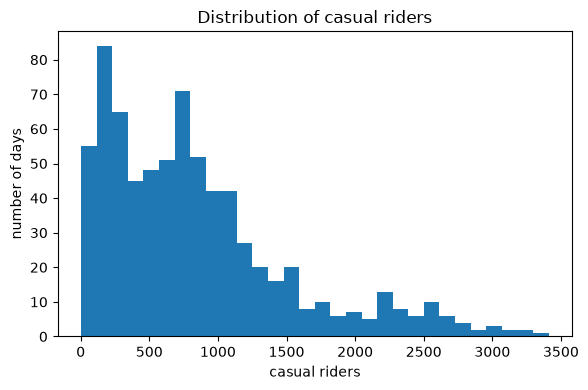

In [11]:
bike = pd.read_csv('../../../data/bike-sharing-daily.csv')

plt.figure(figsize=(6, 4))
plt.hist(bike['casual'], bins=30)
plt.xlabel('casual riders')
plt.ylabel('number of days')
plt.title('Distribution of casual riders')
plt.tight_layout()
plt.show()

**a. The distribution of casual riders is right-skewed, meaning most days have a relatively low number of casual riders, with the long tail out toward a handful of days with very high casual riders.**

R2: 0.6291


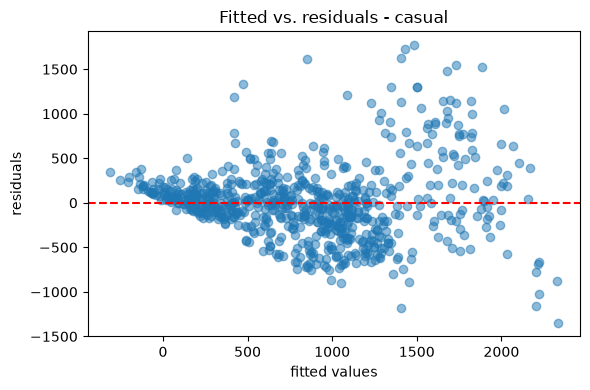

In [12]:
casual_model = smf.ols('casual ~ temp + hum + windspeed + C(workingday)', data=bike).fit()
print("R2:", round(casual_model.rsquared, 4))

plt.figure(figsize=(6, 4))
plt.scatter(casual_model.fittedvalues, casual_model.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('fitted values')
plt.ylabel('residuals')
plt.title('Fitted vs. residuals - casual')
plt.tight_layout()
plt.show()

**b. The residuals fan out from small and tight for low fitted values and a lot more spread out as the fitted values increase. This could be a sign of non-constant variance/heteroscedasticity, which lines up with the right-skewed histogram from part a.**

any zeros in casual? False
R2: 0.6602


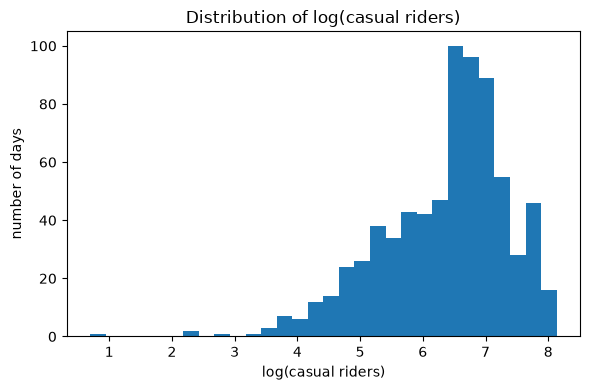

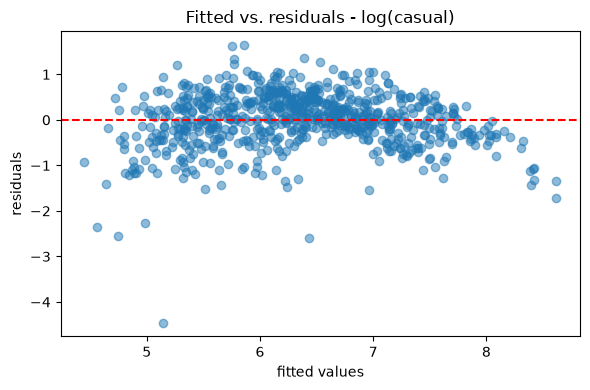

In [13]:
print("any zeros in casual?", (bike['casual'] == 0).any())

# no zeros, so a regular log is fine here (would use np.log1p if there were zeros)
bike['log_casual'] = np.log(bike['casual'])

log_casual_model = smf.ols('log_casual ~ temp + hum + windspeed + C(workingday)', data=bike).fit()
print("R2:", round(log_casual_model.rsquared, 4))

plt.figure(figsize=(6, 4))
plt.hist(bike['log_casual'], bins=30)
plt.xlabel('log(casual riders)')
plt.ylabel('number of days')
plt.title('Distribution of log(casual riders)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(log_casual_model.fittedvalues, log_casual_model.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('fitted values')
plt.ylabel('residuals')
plt.title('Fitted vs. residuals - log(casual)')
plt.tight_layout()
plt.show()

**c. After logging casual riders, the histogram looks a lot more symmetric/bell-shaped instead of right-skewed. The fitted vs. residuals plot also looks much more like a random cloud around zero, without the fanning-out pattern from before, so the constant variance assumption looks a lot more reasonable.**

**d. Yes, it made sense to try a log transformation here because the original histogram was right-skewed, which is the kind of shape where logging the target usually helps. It did have the effect I expected with the histogram becoming more symmetric and the residual fanning went away. This is similar to what we did for Kepler's Law in Lab 2, where logging skewed variables turned a nonlinear relationship into something closer to linear. The difference is that for Kepler's Law we logged both the predictor and the response to linearize the relationship itself, while here we mainly logged the response to fix the non-constant variance in the residuals.**
***

## Part 3: Final Project Update

I'm the one turning in this part of the lab for my group. See PDF in repo.